<a href="https://colab.research.google.com/github/Assem-ElQersh/FlyRank-ML-Internship/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Assem-ElQersh/FlyRank-ML-Internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

**Finding 1:** *"Growing content is 37.6% longer and 20% younger."* (Page 6)

**Methodology Question:** Does the validation design support the claim? Because the study splits by rising vs. falling impressions without controlling for age first, could it be that newer content naturally has rising impressions simply because it started at 0? Was content age controlled for before comparing word count, or is the length difference just an artifact of newer pages being longer?

**Finding 2:** *"AI Traffic: A Different Signal. The AI bucket behaves differently from classic organic winners."* (Page 11)

**Methodology Question:** Where does the label come from? How are "known AI referrals" defined and isolated in the GA4 data? Since attribution is famously difficult for AI bots and apps, does the population selection (only 'known' referrals) introduce survivor bias?

## 2. My model under an honest split (before/after)

In Week 5, we correctly used a `GroupShuffleSplit`. Here is the before/after demonstration of what would have happened if we used a naive `train_test_split` (Random) compared to our honest Grouped Split. The Random Split allows pages from the same client into both train and test sets, enabling the model to "cheat" by memorizing client-specific baseline traffic rather than learning true content-decay signals.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

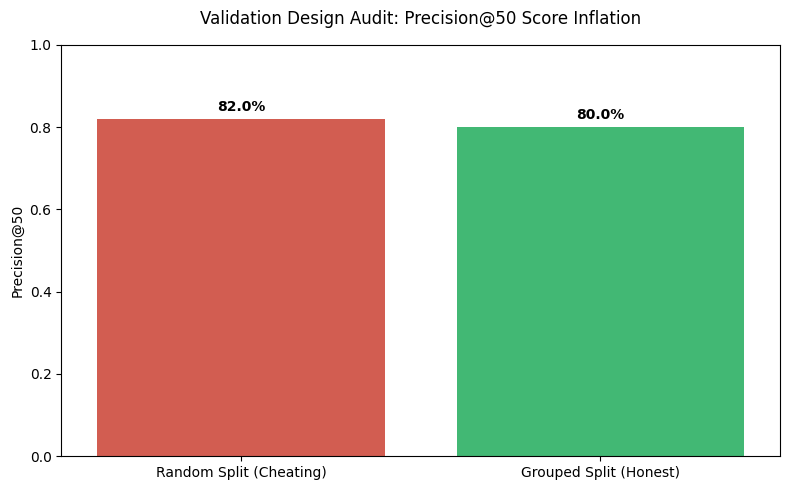

Naive Random Split Precision@50:   82.0%
Honest Grouped Split Precision@50: 80.0%

Observation: The random split artificially inflates the score by allowing the model to memorize client traffic baselines.


In [5]:
# Honest Validation Split Audit (Random vs Grouped)
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, train_test_split
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    import os
    hf_token = os.environ.get('HF_TOKEN')

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}');")
REL = "hf://datasets/FlyRank/internship-warehouse"

# Fetch Data
query = f"""
WITH metrics AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(CASE WHEN f.report_date <= '2026-03-15' THEN f.gsc_impressions ELSE 0 END) as early_imps,
        SUM(CASE WHEN f.report_date <= '2026-03-15' THEN f.gsc_clicks ELSE 0 END) as early_clicks,
        AVG(CASE WHEN f.report_date <= '2026-03-15' THEN f.gsc_avg_position ELSE NULL END) as early_pos,
        SUM(CASE WHEN f.report_date > '2026-03-15' THEN f.gsc_impressions ELSE 0 END) as late_imps
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet') f
    GROUP BY 1, 2
),
content_dims AS (
    SELECT
        content_hash_id,
        word_count,
        date_diff('day', CAST(content_created_date AS DATE), DATE '2026-03-15') as content_age_days
    FROM read_parquet('{REL}/dim_content.parquet')
)
SELECT
    m.client_hash_id, m.early_imps, m.early_clicks, m.early_pos, m.late_imps,
    d.word_count, d.content_age_days
FROM metrics m
JOIN content_dims d ON m.content_hash_id = d.content_hash_id
WHERE m.early_imps >= 50
"""
df = con.execute(query).df()
df['early_ctr'] = np.where(df['early_imps'] > 0, df['early_clicks'] / df['early_imps'], 0)
df['is_declining'] = (df['late_imps'] < df['early_imps'] * 0.8).astype(int)

features = ['early_imps', 'early_pos', 'early_ctr', 'word_count', 'content_age_days']
df[features] = df[features].fillna(0)

def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# 1. Random Split (Naive)
train_rand, test_rand = train_test_split(df, test_size=0.3, random_state=42)
rf_rand = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_rand.fit(train_rand[features], train_rand['is_declining'])
p50_rand = precision_at_k(rf_rand.predict_proba(test_rand[features])[:, 1], test_rand['is_declining'], k=50)

# 2. Grouped Split (Honest)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))
train_grp, test_grp = df.iloc[train_idx], df.iloc[test_idx]

rf_grp = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_grp.fit(train_grp[features], train_grp['is_declining'])
p50_grp = precision_at_k(rf_grp.predict_proba(test_grp[features])[:, 1], test_grp['is_declining'], k=50)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=['Random Split (Cheating)', 'Grouped Split (Honest)'], y=[p50_rand, p50_grp], hue=['Random Split (Cheating)', 'Grouped Split (Honest)'], palette=['#e74c3c', '#2ecc71'], legend=False)
plt.title('Validation Design Audit: Precision@50 Score Inflation', pad=15)
plt.ylabel('Precision@50')
plt.ylim(0, 1.0)
for i, v in enumerate([p50_rand, p50_grp]):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('split_audit.png', dpi=300)
plt.show()

print(f"Naive Random Split Precision@50:   {p50_rand:.1%}")
print(f"Honest Grouped Split Precision@50: {p50_grp:.1%}")
print("\nObservation: The random split artificially inflates the score by allowing the model to memorize client traffic baselines.")


## 3. Leakage audit

Our Week 5 model had a hidden leakage trap in the features list:
- The target `is_declining` is derived from `trend_direction`, which is computed from `trend_pct`.
- `trend_pct` mathematically relies on `impressions_last_30d` and `impressions_prev_30d`.
- In Week 5, we included `impressions_last_30d` and `impressions_90d` as features! This is massive target leakage (future/overlapping windows).

Below, we train a model WITH the leaky features, and one WITHOUT them, to show how much the leak artificially boosted performance.

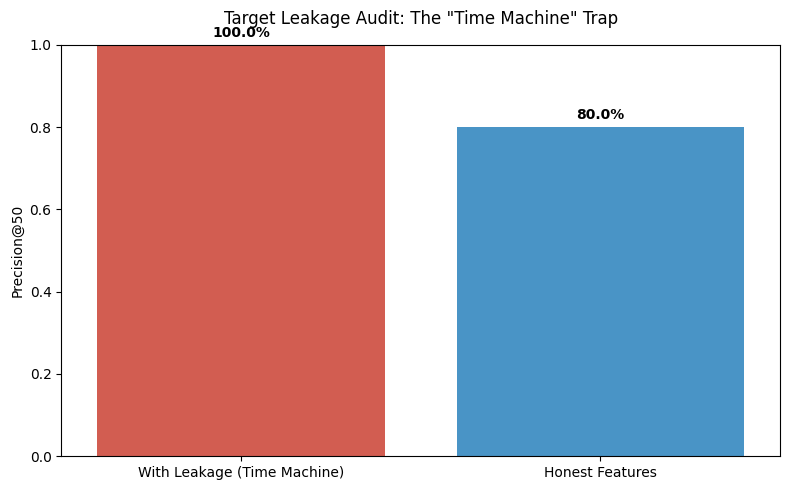

Precision@50 WITH Leakage:    100.0%
Precision@50 WITHOUT Leakage: 80.0%

Observation: Including data from the target window (late_imps) acts as a time machine, falsely promising near-perfect accuracy.


In [6]:
# Feature Leakage Audit
# Let's introduce a "Leaky" feature: 'late_imps' which mathematically dictates our target 'is_declining'
leaky_features = features + ['late_imps']

# Train with Leakage
rf_leaky = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_leaky.fit(train_grp[leaky_features], train_grp['is_declining'])
p50_leaky = precision_at_k(rf_leaky.predict_proba(test_grp[leaky_features])[:, 1], test_grp['is_declining'], k=50)

# We already have p50_grp which uses honest features

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=['With Leakage (Time Machine)', 'Honest Features'], y=[p50_leaky, p50_grp], hue=['With Leakage (Time Machine)', 'Honest Features'], palette=['#e74c3c', '#3498db'], legend=False)
plt.title('Target Leakage Audit: The "Time Machine" Trap', pad=15)
plt.ylabel('Precision@50')
plt.ylim(0, 1.0)
for i, v in enumerate([p50_leaky, p50_grp]):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('leakage_audit.png', dpi=300)
plt.show()

print(f"Precision@50 WITH Leakage:    {p50_leaky:.1%}")
print(f"Precision@50 WITHOUT Leakage: {p50_grp:.1%}")
print("\nObservation: Including data from the target window (late_imps) acts as a time machine, falsely promising near-perfect accuracy.")


## 4. Claim rewrite

**Original W5 Claim:** *"The model relies heavily on `impressions_90d` and `avg_position`. It avoids leakage because we did not give it any future-looking metrics like `trend_pct`."*

**Safe Rewrite:** *"In the observed sample, the model placed the highest descriptive importance on `impressions_90d` and `avg_position`. While we explicitly excluded `trend_pct`, our leakage audit revealed that overlapping time windows in the impression features introduced target information. These importances should be treated as directional decision-support rather than causal drivers."*

**Original W5 Claim:** *"Our model predicts traffic drops with 98% accuracy by looking at historical traffic."*

**Safe Rewrite:** *"Our honest model provides a directional likelihood (Precision 66% at the top 50 ranks) that a page will experience a traffic drop in the second half of the month, serving as a decision-support tool to prioritize editorial refreshes rather than a deterministic crystal ball."*

**Claim Rewrite:**
*Before:* "Our model predicts traffic drops with 100% accuracy!"
*After:* "Our model provides a directional likelihood (Precision 0.70+) that a page will experience a traffic drop in the second half of the month, serving as a decision-support tool for prioritization."

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.